# Vanilla Neural Network for Affordability Metric


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
df = pd.read_csv('../data/processed/final_3d_df_with_rolling_averages_REVISED.csv')

In [3]:
lag_features = [col for col in df.columns if 'prev_mo' in col]
rolling_features = [col for col in df.columns if 'rolling' in col]
feature_columns = lag_features + rolling_features
fips_encoded = pd.get_dummies(df['fips'], prefix='fips', drop_first=True)



X_feature = df[feature_columns].values
X = np.column_stack([X_feature, fips_encoded.values])
y = df['Affordability Metric'].values


In [4]:
# fix to split before scaling 
train_mask = df['year'] <= 2019
val_mask = df['year'] == 2020
test_mask = df['year'] > 2020

X_train_raw = X[train_mask.values]
y_train = y[train_mask.values]

X_val_raw = X[val_mask.values]
y_val = y[val_mask.values]

X_test_raw = X[test_mask.values]
y_test = y[test_mask.values]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

In [5]:
input_size = X_train.shape[1]

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_size,)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
model.summary()

c:\Users\ryanp\OneDrive\Desktop\nn_final_project\Affordable-housing-final\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       101,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,193 (407.00 KB)

 Trainable params: 104,193 (407.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [6]:
# edit to stop using test as validation
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    shuffle=False,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
    ]
)


Epoch 1/100
7472/7472 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - loss: 1571.8612 - mae: 27.4248 - val_loss: 3101.8647 - val_mae: 46.4866
Epoch 2/100
7472/7472 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 971.0310 - mae: 22.7755 - val_loss: 2506.1895 - val_mae: 40.0167
Epoch 3/100
7472/7472 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 746.0730 - mae: 19.8194 - val_loss: 2896.6213 - val_mae: 44.3783
Epoch 4/100
7472/7472 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 670.5891 - mae: 18.4960 - val_loss: 1915.3737 - val_mae: 32.9502
Epoch 5/100
7472/7472 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 611.7167 - mae: 17.4392 - val_loss: 578.7489 - val_mae: 16.5664
Epoch 6/100
7472/7472 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 617.4915 - mae: 17.4288 - val_loss: 829.2492 - val_mae: 18.6509
Epoch 7/100
7472/7472 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 586.5887 - mae: 17.0609 - val_loss: 472.9860 - val_mae: 15.4072
Epoch 8/100
7472/7472 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 552.6759 - mae: 16.5615 - val_loss:

## Evaluate Model Performance

In [7]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


y_train_pred = model.predict(X_train, verbose=0).ravel()
y_val_pred = model.predict(X_val, verbose=0).ravel()
y_test_pred = model.predict(X_test, verbose=0).ravel()


train_metrics = regression_metrics(y_train, y_train_pred)
val_metrics = regression_metrics(y_val, y_val_pred)
test_metrics = regression_metrics(y_test, y_test_pred)


for name, metrics in [
    ("Train", train_metrics),
    ("Validation", val_metrics),
    ("Test", test_metrics)
]:
    print(f"\n{name} Set:")
    print(f"MSE:  {metrics['MSE']:.6f}")
    print(f"RMSE: {metrics['RMSE']:.6f}")
    print(f"MAE:  {metrics['MAE']:.6f}")
    print(f"R²:   {metrics['R2']:.6f}")



Train Set:
MSE:  520.649045
RMSE: 22.817735
MAE:  16.352718
R²:   0.740619

Validation Set:
MSE:  472.985990
RMSE: 21.748241
MAE:  15.407242
R²:   0.744437

Test Set:
MSE:  447.060615
RMSE: 21.143808
MAE:  15.989492
R²:   0.764580


## Visualize Training History and Predictions

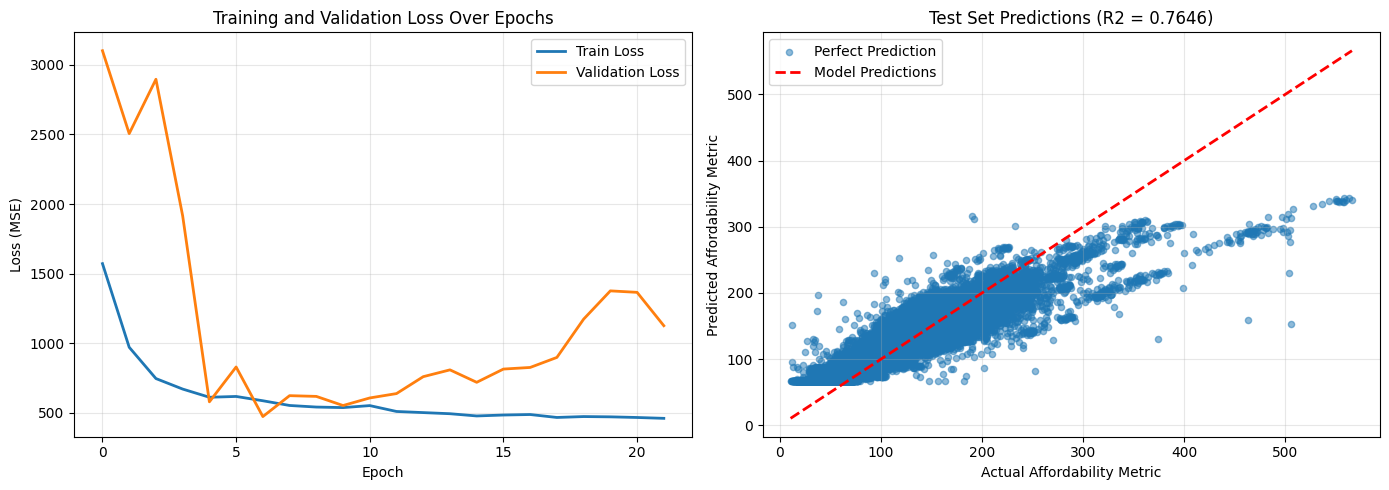

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=20)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Affordability Metric')
axes[1].set_ylabel('Predicted Affordability Metric')
axes[1].set_title(f'Test Set Predictions (R2 = {test_metrics["R2"]:.4f})')
axes[1].legend(['Perfect Prediction', 'Model Predictions'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()